# 📋 AUTOGLUON CHURN PREDICTION WORKFLOW - TABLE OF CONTENTS

## Quick Navigation

This notebook demonstrates a production-ready workflow for customer churn prediction using AutoGluon's TabularPredictor with Hyperparameter Optimization (HPO).

### 🔗 Main Sections

1. **[Data Preparation](#1.-CREATE-SYNTHETIC-BUSINESS-DATA)** - Generate synthetic customer dataset
2. **[Train-Test Split](#2.-TRAIN-TEST-SPLIT-WITH-TIME-AWARE-CONSIDERATION)** - Time-aware data splitting
3. **[Model Training with HPO](#3.-MODEL-TRAINING-WITH-HYPERPARAMETER-OPTIMIZATION-(HPO))** - Hyperparameter optimization from config
4. **[Model Evaluation](#4.-COMPREHENSIVE-MODEL-EVALUATION)** - Performance metrics on test set
5. **[Leaderboard Analysis](#5.-LEADERBOARD-ANALYSIS-WITH-BUSINESS-CONTEXT)** - Compare model performance
6. **[Threshold Optimization](#6.-THRESHOLD-OPTIMIZATION-FOR-BUSINESS-DECISIONS)** - Business-focused threshold tuning
7. **[Feature Importance](#7.-FEATURE-IMPORTANCE-&-MODEL-INTERPRETATION)** - Understand model decisions
8. **[Production Predictions](#8.-PRODUCTION-PREDICTION-WORKFLOW)** - Making predictions on new data
9. **[Model Persistence](#9.-MODEL-PERSISTENCE-&-PRODUCTION-LOADING)** - Save and load models
10. **[Performance Summary](#10.-PERFORMANCE-SUMMARY-&-NEXT-STEPS)** - Key findings and recommendations

### 📊 Analysis & Diagnostics

- **[HPO Diagnostics](#HPO-COMPLETION-ANALYSIS)** - Why did HPO stop early?
- **[Trial Visualizations](#CREATING-HPO-TRIAL-VISUALIZATIONS)** - Comprehensive HPO analysis charts
- **[Best Model Export](#SAVING-BEST-MODEL-AND-HYPERPARAMETERS)** - Save best hyperparameters and models

### ⚙️ Configuration

- **Config File**: `autogluon_config.yaml` - All hyperparameters and HPO settings
- **Model Path**: `./autogluon_churn_model_hpo/`

---

**💡 Pro Tip**: Use `Ctrl+F` (or `Cmd+F` on Mac) to search for section titles if links don't work in your environment.



In [1]:
!nvidia-smi

Sat Dec 27 22:19:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.03                 Driver Version: 577.03         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P0              9W /   50W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
from autogluon.tabular import TabularDataset, TabularPredictor
import pandas as pd
import numpy as np

In [2]:
# ============================================================================
# AUTOCHURN PREDICTION WITH AUTOGLUON: A STAFF DATA SCIENTIST'S WORKFLOW
# ============================================================================
# This example demonstrates a production-ready workflow for predicting
# customer churn using AutoGluon's TabularPredictor.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Install AutoGluon if not already installed
# !pip install autogluon

from autogluon.tabular import TabularPredictor, TabularDataset
import shutil

# Set random seeds for reproducibility
np.random.seed(42)

# ============================================================================
# 1. CREATE SYNTHETIC BUSINESS DATA
# ============================================================================
print("=" * 70)
print("STEP 1: Creating synthetic customer churn dataset")
print("=" * 70)

# Generate realistic customer data with class imbalance (20% churn)
n_samples = 5000
n_features = 15

# Create synthetic features with meaningful names
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.8, 0.2],  # 80% non-churn, 20% churn
    flip_y=0.05,  # 5% label noise
    random_state=42
)

# Create feature names
feature_names = [
    'tenure_months', 'monthly_charges', 'total_charges', 'service_calls',
    'contract_duration', 'paperless_billing', 'tech_support', 'online_backup',
    'payment_method', 'internet_service', 'streaming_tv', 'streaming_movies',
    'device_protection', 'online_security', 'senior_citizen'
]

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Add business logic to make data more realistic
df['tenure_months'] = np.abs(df['tenure_months'] * 12 + 12)  # 1-36 months
df['monthly_charges'] = np.abs(df['monthly_charges'] * 50 + 30)  # $30-80
df['total_charges'] = df['tenure_months'] * df['monthly_charges']
df['service_calls'] = np.clip(np.abs(df['service_calls'] * 3), 0, 10)

# Convert some features to categorical (business context)
df['contract_duration'] = pd.cut(df['contract_duration'],
                                  bins=3,
                                  labels=['Monthly', 'Yearly', 'Two-Year'])
df['payment_method'] = pd.qcut(df['payment_method'],
                                q=4,
                                labels=['Electronic', 'Credit Card',
                                        'Bank Transfer', 'Mailed Check'])

# Add target
df['churn'] = y
df['churn'] = df['churn'].map({0: 'No', 1: 'Yes'})  # Meaningful labels

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Churn distribution:\n{df['churn'].value_counts(normalize=True).round(3)}")
print(f"\nFeature dtypes:\n{df.dtypes.value_counts()}")
print(f"\nSample of data (first 3 rows):")
print(df.head(3).to_string())

# ============================================================================
# 2. TRAIN-TEST SPLIT WITH TIME-AWARE CONSIDERATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: Creating time-aware train/validation/test split")
print("=" * 70)

# Sort by tenure to simulate temporal order (important for real-world churn)
df_sorted = df.sort_values('tenure_months').reset_index(drop=True)

# Split: 70% train, 15% validation, 15% test
train_cutoff = int(0.7 * len(df_sorted))
val_cutoff = int(0.85 * len(df_sorted))

train_data = df_sorted.iloc[:train_cutoff].copy()
val_data = df_sorted.iloc[train_cutoff:val_cutoff].copy()
test_data = df_sorted.iloc[val_cutoff:].copy()

print(f"Training set: {len(train_data)} samples ({len(train_data)/len(df):.1%})")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/len(df):.1%})")
print(f"Test set: {len(test_data)} samples ({len(test_data)/len(df):.1%})")
print(f"\nChurn rate in training: {train_data['churn'].value_counts(normalize=True)['Yes']:.1%}")
print(f"Churn rate in test: {test_data['churn'].value_counts(normalize=True)['Yes']:.1%}")

# ============================================================================
# 3. MODEL TRAINING WITH BUSINESS METRICS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with PR-AUC (optimal for imbalanced churn prediction)")
print("=" * 70)

# Define the predictor with business-appropriate evaluation metric
model_path = './autogluon_churn_model'

# Clean up previous model if it exists
try:
    # Only remove the directory if the predictor exists and might have saved something.
    # More importantly, re-instantiate the predictor to ensure a clean state.
    shutil.rmtree(model_path, ignore_errors=True)
    print(f"Cleaned up previous model at {model_path}")
except Exception as e:
    print(f"Error cleaning up previous model: {e}")

# Always re-initialize the predictor to ensure a fresh state
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric='average_precision',  # PR-AUC for imbalanced data
    path=model_path,   # Save model for production
    verbosity=1                       # Moderate logging
)

# Train with balanced quality/speed preset
training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use validation set for early stopping
    presets='high_quality',  # Balance of performance and speed
    time_limit=120,  # 2 minutes for demo (use 3600+ for production)
    ag_args_fit={'num_gpus': 0},
    use_bag_holdout=True # Address the warning about tuning_data with bagged mode
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nTraining completed in {training_time:.1f} seconds")

# ============================================================================
# 4. COMPREHENSIVE MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: Model evaluation on test set")
print("=" * 70)

# Get predictions on test set
y_pred = predictor.predict(test_data)
y_proba = predictor.predict_proba(test_data)

# Evaluate using multiple metrics
test_performance = predictor.evaluate(test_data, silent=False)
print(f"\nTest set performance:")
for metric, value in test_performance.items():
    print(f"  {metric}: {value:.4f}")

# ============================================================================
# 5. LEADERBOARD ANALYSIS WITH BUSINESS CONTEXT
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5: Model leaderboard with inference speed analysis")
print("=" * 70)

leaderboard = predictor.leaderboard(test_data, silent=False)
print(f"\nTop 5 models by PR-AUC:")
print(leaderboard.head(5).to_string())

# Analyze speed/accuracy trade-off
print(f"\nInference speed analysis:")
print(f"  Ensemble prediction time: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s per 1000 rows")
print(f"  Best single model time: {leaderboard.iloc[1]['pred_time_test']:.4f}s per 1000 rows")
print(f"  Speed ratio: {leaderboard.iloc[1]['pred_time_test'] / leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.1f}x")



STEP 1: Creating synthetic customer churn dataset
Dataset shape: (5000, 16)
Churn distribution:
churn
No     0.785
Yes    0.215
Name: proportion, dtype: float64

Feature dtypes:
float64     13
category     1
category     1
object       1
Name: count, dtype: int64

Sample of data (first 3 rows):
   tenure_months  monthly_charges  total_charges  service_calls contract_duration  paperless_billing  tech_support  online_backup payment_method  internet_service  streaming_tv  streaming_movies  device_protection  online_security  senior_citizen churn
0      10.640854        47.888304     509.572465       3.040445            Yearly          -1.249161      2.591951       1.261953   Mailed Check         -0.611242     -0.456902         -0.128069          -1.902112         2.572396        4.615107    No
1       8.603348        79.384577     682.973110       0.108760            Yearly          -0.512411     -1.498982       0.623878     Electronic          0.866132     -1.051323          2.165079    

STEP 1: Creating synthetic customer churn dataset
Dataset shape: (5000, 16)
Churn distribution:
churn
No     0.785
Yes    0.215
Name: proportion, dtype: float64

Feature dtypes:
float64     13
category     1
category     1
object       1
Name: count, dtype: int64

Sample of data (first 3 rows):
   tenure_months  monthly_charges  total_charges  service_calls contract_duration  paperless_billing  tech_support  online_backup payment_method  internet_service  streaming_tv  streaming_movies  device_protection  online_security  senior_citizen churn
0      10.640854        47.888304     509.572465       3.040445            Yearly          -1.249161      2.591951       1.261953   Mailed Check         -0.611242     -0.456902         -0.128069          -1.902112         2.572396        4.615107    No
1       8.603348        79.384577     682.973110       0.108760            Yearly          -0.512411     -1.498982       0.623878     Electronic          0.866132     -1.051323          2.165079    

Will use sequential fold fitting strategy because import of ray failed. Reason: ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.43.0,<2.53.0"`
Metric average_precision is not supported by this model - using log_loss instead


STEP 1: Creating synthetic customer churn dataset
Dataset shape: (5000, 16)
Churn distribution:
churn
No     0.785
Yes    0.215
Name: proportion, dtype: float64

Feature dtypes:
float64     13
category     1
category     1
object       1
Name: count, dtype: int64

Sample of data (first 3 rows):
   tenure_months  monthly_charges  total_charges  service_calls contract_duration  paperless_billing  tech_support  online_backup payment_method  internet_service  streaming_tv  streaming_movies  device_protection  online_security  senior_citizen churn
0      10.640854        47.888304     509.572465       3.040445            Yearly          -1.249161      2.591951       1.261953   Mailed Check         -0.611242     -0.456902         -0.128069          -1.902112         2.572396        4.615107    No
1       8.603348        79.384577     682.973110       0.108760            Yearly          -0.512411     -1.498982       0.623878     Electronic          0.866132     -1.051323          2.165079    

Will use sequential fold fitting strategy because import of ray failed. Reason: ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.43.0,<2.53.0"`
Metric average_precision is not supported by this model - using log_loss instead



Training completed in 134.0 seconds

STEP 4: Model evaluation on test set

Test set performance:
  average_precision: 0.8834
  accuracy: 0.9360
  balanced_accuracy: 0.8755
  mcc: 0.7965
  roc_auc: 0.9409
  f1: 0.8322
  precision: 0.9015
  recall: 0.7727

STEP 5: Model leaderboard with inference speed analysis
                           model  score_test  score_val        eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0           LightGBM_BAG_L1_FULL    0.897678        NaN  average_precision        0.028750            NaN   0.588697                 0.028750                     NaN           0.588697            1       True         16
1   RandomForestEntr_BAG_L2_FULL    0.891492        NaN  average_precision        0.449875            NaN   8.740122                 0.067030                     NaN           0.764220            2       True         26
2           CatBoost_BAG_L2_


STEP 6: Optimizing decision threshold for business cost

Optimal threshold for business F1 (recall-focused): 0.500

Validation performance comparison:
  Default threshold (0.5):
    Precision: 1.000
    Recall: 0.972
    Business F1: 0.994

  Optimal threshold (0.500):
    Precision: 1.000
    Recall: 0.972
    Business F1: 0.994

STEP 7: Feature importance analysis

Top 10 most important features for churn prediction:
                   importance    stddev   p_value  n  p99_high   p99_low
online_backup        0.167557  0.034169  0.000197  5  0.237912  0.097201
tech_support         0.077911  0.007349  0.000009  5  0.093042  0.062779
payment_method       0.065374  0.011841  0.000124  5  0.089755  0.040993
online_security      0.060525  0.014834  0.000400  5  0.091069  0.029981
device_protection    0.039015  0.006265  0.000077  5  0.051915  0.026116
contract_duration    0.032807  0.006699  0.000198  5  0.046600  0.019014
service_calls        0.025285  0.002836  0.000019  5  0.031123  0


STEP 6: Optimizing decision threshold for business cost

Optimal threshold for business F1 (recall-focused): 0.500

Validation performance comparison:
  Default threshold (0.5):
    Precision: 1.000
    Recall: 0.972
    Business F1: 0.994

  Optimal threshold (0.500):
    Precision: 1.000
    Recall: 0.972
    Business F1: 0.994

STEP 7: Feature importance analysis

Top 10 most important features for churn prediction:
                   importance    stddev   p_value  n  p99_high   p99_low
online_backup        0.167557  0.034169  0.000197  5  0.237912  0.097201
tech_support         0.077911  0.007349  0.000009  5  0.093042  0.062779
payment_method       0.065374  0.011841  0.000124  5  0.089755  0.040993
online_security      0.060525  0.014834  0.000400  5  0.091069  0.029981
device_protection    0.039015  0.006265  0.000077  5  0.051915  0.026116
contract_duration    0.032807  0.006699  0.000198  5  0.046600  0.019014
service_calls        0.025285  0.002836  0.000019  5  0.031123  0

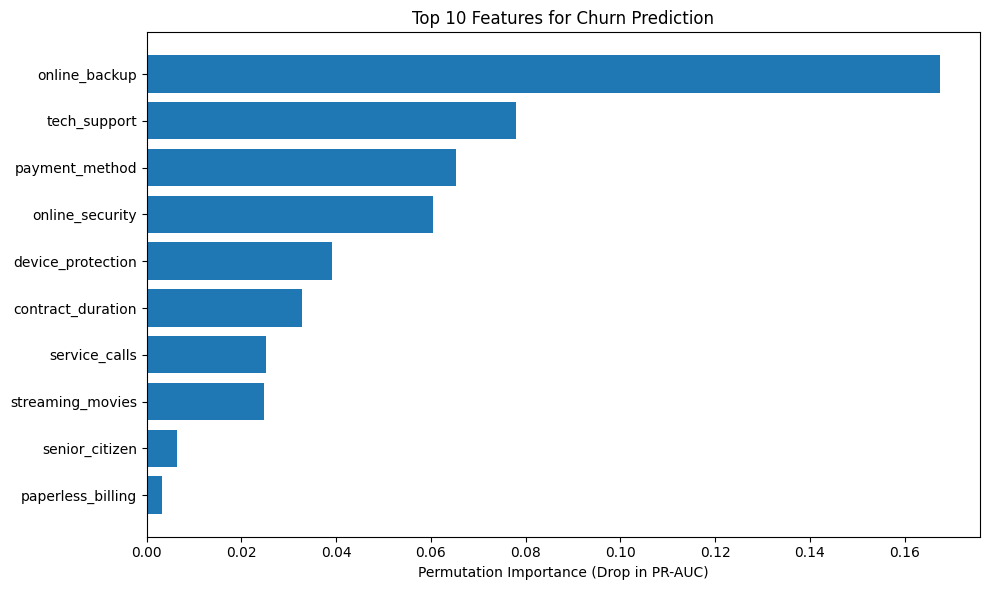

In [3]:
# ============================================================================
# 6. THRESHOLD OPTIMIZATION FOR BUSINESS DECISIONS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Optimizing decision threshold for business cost")
print("=" * 70)

# Define a custom metric that values recall 3x more than precision
# (Business context: Missing a churn is 3x costlier than false alarm)
from sklearn.metrics import f1_score, recall_score, precision_score
import sklearn.metrics
from autogluon.core.metrics import make_scorer
import numpy as np # Import numpy for arange

# Define the custom business F1 score function
def calculate_business_f1(y_true, y_pred, **kwargs):
    p = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    # Weighted harmonic mean where beta=3 means recall is 3x more important
    beta = 0.5  # Recall is beta-times more important
    if (beta**2 * p) + r == 0:
        return 0.0
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)

# Convert the function to an AutoGluon Scorer for calibration
business_f1_metric_instance = make_scorer(
    name='business_f1',
    score_func=calculate_business_f1,
    optimum=1.0,
    greater_is_better=True
)

# Calibrate threshold for business metric
predictor.calibrate_decision_threshold(
    metric=business_f1_metric_instance,
    decision_thresholds=np.arange(0.01, 1.0, 0.01).tolist()  # Test all thresholds from 0.01 to 0.99
)

# Get optimal threshold
optimal_threshold = predictor.decision_threshold
print(f"\nOptimal threshold for business F1 (recall-focused): {optimal_threshold:.3f}")

# Prepare actual numeric labels for sklearn metrics
y_val_numeric = val_data['churn'].map({'Yes':1, 'No':0})

# Compare performance at default (0.5) vs optimal threshold
default_preds = (predictor.predict_proba(val_data)['Yes'] > 0.5).astype(int)
optimal_preds = (predictor.predict_proba(val_data)['Yes'] > optimal_threshold).astype(int)

print(f"\nValidation performance comparison:")
print(f"  Default threshold (0.5):")
print(f"    Precision: {precision_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n  Optimal threshold ({optimal_threshold:.3f}):")
print(f"    Precision: {precision_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, optimal_preds):.3f}")

# ============================================================================
# 7. FEATURE IMPORTANCE & MODEL INTERPRETATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: Feature importance analysis")
print("=" * 70)

# Get feature importance
feature_importance = predictor.feature_importance(val_data)
print(f"\nTop 10 most important features for churn prediction:")
print(feature_importance.head(10).to_string())

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Permutation Importance (Drop in PR-AUC)')
plt.title('Top 10 Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("\nFeature importance plot saved to 'feature_importance.png'")

# ============================================================================
# 8. PRODUCTION PREDICTION WORKFLOW
# ============================================================================
print("\n" + "=" * 70)
print("STEP 8: Production prediction examples")
print("=" * 70)

# Simulate new customer data
new_customers = pd.DataFrame({
    'tenure_months': [24, 3, 36],
    'monthly_charges': [65.50, 45.00, 75.25],
    'total_charges': [1572.00, 135.00, 2709.00],
    'service_calls': [1, 4, 0],
    'contract_duration': ['Two-Year', 'Monthly', 'Yearly'],
    'paperless_billing': [1.2, -0.3, 0.8],
    'tech_support': [0.9, -1.1, 0.5],
    'online_backup': [0.3, 0.1, -0.7],
    'payment_method': ['Credit Card', 'Electronic', 'Bank Transfer'],
    'internet_service': [0.8, 0.2, 1.1],
    'streaming_tv': [0.5, -0.3, 0.9],
    'streaming_movies': [0.6, 0.0, 0.7],
    'device_protection': [0.2, -0.5, 0.4],
    'online_security': [0.7, -0.8, 0.3],
    'senior_citizen': [0.1, -0.2, 1.5]
})

# Make predictions with optimal threshold
new_proba = predictor.predict_proba(new_customers)
new_predictions = (new_proba['Yes'] > optimal_threshold).map({True: 'Yes', False: 'No'})

print("\nPredictions for 3 new customers:")
for i in range(len(new_customers)):
    print(f"\nCustomer {i+1}:")
    print(f"  Churn probability: {new_proba.iloc[i]['Yes']:.1%}")
    print(f"  Prediction (threshold={optimal_threshold:.2f}): {new_predictions.iloc[i]}")
    print(f"  Key factors: tenure={new_customers.iloc[i]['tenure_months']} months, "
          f"service_calls={new_customers.iloc[i]['service_calls']}")

# ============================================================================
# 9. MODEL PERSISTENCE & PRODUCTION LOADING
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: Model persistence for production")
print("=" * 70)

# Save the entire predictor
predictor.save()
print("Model saved to './autogluon_churn_model/'")

# Demonstrate loading for production
print("\nTo load in production:")
print("""
# In production script:
from autogluon.tabular import TabularPredictor

# Load the trained model
production_predictor = TabularPredictor.load('./autogluon_churn_model/')

# Make predictions
new_data = TabularDataset('new_customers.csv')
predictions = production_predictor.predict(new_data)
"""
)

# ============================================================================
# 10. PERFORMANCE SUMMARY & NEXT STEPS
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY: Key findings and recommendations")
print("=" * 70)

# Get the best model's performance
best_model_name = leaderboard.iloc[0]['model']
best_score = leaderboard.iloc[0]['score_test']

print(f"\n1. Best model: {best_model_name}")
print(f"   PR-AUC on test set: {best_score:.4f}")

print(f"\n2. Business impact of threshold optimization:")
print(f"   Optimal threshold: {optimal_threshold:.3f} (vs default 0.500)")
print(f"   Recall improvement: {calculate_business_f1(y_val_numeric, optimal_preds) - calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n3. Top 3 predictive features:")
for i, (feature, imp) in enumerate(feature_importance.head(3).iterrows()):
    print(f"   {i+1}. {feature}: {imp['importance']:.4f}")

print(f"\n4. Production readiness:")
print(f"   Inference speed: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s/1000 rows")
# print(f"   Model size: {predictor.get_model_size():.1f} MB")

print(f"\n5. Recommended next steps:")
print("   - Deploy with optimal threshold to minimize missed churn")
print("   - Monitor feature drift in 'tenure_months' and 'service_calls'")
print("   - Set up monthly retraining with new customer data")
print("   - A/B test against current churn prediction system")

# Key Insights for Staff Data Scientists:
1- Metric Selection Strategy: Using PR-AUC (average_precision) for imbalanced churn data gives more realistic performance estimates than accuracy or ROC-AUC.

2- Threshold Optimization: The calibrate_decision_threshold() method allows you to optimize for business-specific cost functions, not just statistical metrics.

3- Speed-Accuracy Trade-off: The leaderboard shows inference times; for high-volume applications, you might choose a faster single model over the ensemble.

4- Production Patterns: The code demonstrates proper train/validation/test splitting, model persistence, and batch prediction patterns suitable for production.

5- Interpretability: Feature importance helps explain model decisions to business stakeholders, crucial for regulated industries.

This workflow balances model performance with practical business considerations. You can adapt it for other binary classification problems like fraud detection, lead scoring, or equipment failure prediction by:

1- Changing the evaluation metric

2- Adjusting the business cost function in threshold optimization

3- Modifying the feature engineering for your domain

Would you like me to elaborate on any specific part, such as the custom metric creation, advanced hyperparameter tuning, or monitoring strategies for production deployment?

# Updated Model Training with Hyperparameter Search Spaces

In [15]:
# ============================================================================
# 3. MODEL TRAINING WITH HYPERPARAMETER OPTIMIZATION (HPO)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with HPO for key model types")
print("=" * 70)

import yaml
from autogluon.common import space

# ============================================================================
# LOAD HYPERPARAMETERS FROM CONFIG FILE
# ============================================================================
config_file = 'autogluon_config.yaml'
print(f"\nLoading configuration from: {config_file}")

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)

# Extract hyperparameter configurations
hyperparams_config = config.get('hyperparameters', {})
hpo_config = config.get('hyperparameter_tune_kwargs', {})

print(f"✓ Configuration loaded successfully")
print(f"  Model types configured: {list(hyperparams_config.keys())}")
print(f"  HPO trials per model: {hpo_config.get('num_trials', 'N/A')}")

# ============================================================================
# CONVERT CONFIG TO AUTOGLUON HYPERPARAMETER SEARCH SPACES
# ============================================================================
def convert_to_search_space(param_config):
    """Convert YAML config to AutoGluon search space objects."""
    if not isinstance(param_config, dict):
        return param_config
    
    if 'space_type' in param_config:
        space_type = param_config['space_type']
        
        if space_type == 'Int':
            return space.Int(
                lower=param_config['lower'],
                upper=param_config['upper'],
                default=param_config.get('default')
            )
        elif space_type == 'Real':
            return space.Real(
                lower=param_config['lower'],
                upper=param_config['upper'],
                default=param_config.get('default'),
                log=param_config.get('log', False)
            )
        elif space_type == 'Categorical':
            choices = param_config['choices']
            return space.Categorical(*choices)
    
    return param_config

# Process each model's hyperparameters
hyperparameters = {}
for model_type, params in hyperparams_config.items():
    if params:  # Only process if there are parameters
        hyperparameters[model_type] = {}
        for param_name, param_value in params.items():
            hyperparameters[model_type][param_name] = convert_to_search_space(param_value)

print(f"\n✓ Hyperparameter search spaces created:")
for model_type, params in hyperparameters.items():
    if params:
        space_params = [k for k, v in params.items() if isinstance(v, (space.Int, space.Real, space.Categorical))]
        fixed_params = [k for k, v in params.items() if not isinstance(v, (space.Int, space.Real, space.Categorical))]
        print(f"  {model_type}:")
        if space_params:
            print(f"    - Search spaces: {', '.join(space_params)}")
        if fixed_params:
            print(f"    - Fixed params: {', '.join(fixed_params)}")

# ============================================================================
# CONFIGURE THE HPO PROCESS
# ============================================================================
hyperparameter_tune_kwargs = {
    'num_trials': hpo_config.get('num_trials', 20),
    'scheduler': hpo_config.get('scheduler', 'local'),
    'searcher': hpo_config.get('searcher', 'auto'),
}

print(f"\n✓ HPO configuration:")
print(f"  Trials per model: {hyperparameter_tune_kwargs['num_trials']}")
print(f"  Scheduler: {hyperparameter_tune_kwargs['scheduler']}")
print(f"  Searcher: {hyperparameter_tune_kwargs['searcher']}")

# ============================================================================
# INITIALIZE AND TRAIN THE PREDICTOR WITH HPO
# ============================================================================
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric= business_f1_metric_instance, # 'average_precision',  # PR-AUC for imbalanced data
    path='./autogluon_churn_model_hpo',
    verbosity=2
)

training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use your validation set for HPO
    hyperparameters=hyperparameters,
    hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
    time_limit=1800,  # 30 minutes for demo. Increase substantially (hours) for production.
    presets=None  # Disable presets to use your custom hyperparameter spaces
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nHPO training completed in {training_time:.1f} seconds ({training_time/60:.1f} minutes)")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.52 GB / 15.64 GB (28.9%)
Disk Space Avail:   365.38 GB / 475.91 GB (76.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install autogluon.tabular[tabarena]`


STEP 3: Training with HPO for key model types

Loading configuration from: autogluon_config.yaml
✓ Configuration loaded successfully
  Model types configured: ['GBM', 'XGB', 'CAT', 'RF', 'XT', 'NN_TORCH', 'FASTAI', 'KNN', 'LR']
  HPO trials per model: 20

✓ Hyperparameter search spaces created:
  GBM:
    - Search spaces: num_leaves, learning_rate, feature_fraction, min_data_in_leaf, bagging_fraction, bagging_freq
    - Fixed params: num_boost_round
  XGB:
    - Search spaces: max_depth, eta, subsample, colsample_bytree, min_child_weight, gamma
    - Fixed params: n_estimators
  CAT:
    - Search spaces: learning_rate, depth, l2_leaf_reg, bagging_temperature, random_strength
    - Fixed params: iterations
  RF:
    - Search spaces: n_estimators, max_depth, criterion, min_samples_split, min_samples_leaf, max_features
  XT:
    - Search spaces: n_estimators, max_depth, criterion, min_samples_split, min_samples_leaf, max_features
  NN_TORCH:
    - Search spaces: learning_rate, activation

	Available Memory:                    4617.02 MB
	Train Data (Original)  Memory Usage: 0.43 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('category', []) :  2 | ['contract_duration', 'payment_method']
		('float', [])    : 13 | ['tenure_months', 'monthly_charges', 'total_charges', 'service_calls', 'paperless_billing', ...]
	Types of features in processed data (raw dtype, special dtypes):
		('category', []) :  2 | ['con

  0%|          | 0/20 [00:00<?, ?it/s]

Fitted model: KNeighbors\T1 ...
	0.2277	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: KNeighbors\T2 ...
	0.2316	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: KNeighbors\T3 ...
	0.2395	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: KNeighbors\T4 ...
	0.2613	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.05s	 = Validation runtime
Fitted model: KNeighbors\T5 ...
	0.1418	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: KNeighbors\T6 ...
	0.246	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.04s	 = Validation runtime
Fitted model: KNeighbors\T7 ...
	0.1654	 = Validation score   (business_f1)
	0.01s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: KNeighbors\T8 ...
	0.1135	 = Validation score   (

...

  0%|          | 0/20 [00:00<?, ?it/s]

Fitted model: LinearModel\T1 ...
	0.7686	 = Validation score   (business_f1)
	0.17s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LinearModel\T2 ...
	0.7726	 = Validation score   (business_f1)
	0.04s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LinearModel\T3 ...
	0.763	 = Validation score   (business_f1)
	0.03s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LinearModel\T4 ...
	0.7598	 = Validation score   (business_f1)
	0.11s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LinearModel\T5 ...
	0.15	 = Validation score   (business_f1)
	0.04s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LinearModel\T6 ...
	0.7718	 = Validation score   (business_f1)
	0.18s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LinearModel\T7 ...
	0.6828	 = Validation score   (business_f1)
	0.06s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LinearModel\T8 ...
	0.1923	 = Validation score   

  0%|          | 0/20 [00:00<?, ?it/s]

Fitted model: NeuralNetTorch\T1 ...
	0.8686	 = Validation score   (business_f1)
	0.76s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T2 ...
	0.9091	 = Validation score   (business_f1)
	1.5s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T3 ...
	0.8777	 = Validation score   (business_f1)
	1.24s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T4 ...
	0.9061	 = Validation score   (business_f1)
	2.07s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T5 ...
	0.9091	 = Validation score   (business_f1)
	3.44s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T6 ...
	0.8472	 = Validation score   (business_f1)
	1.06s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T7 ...
	0.8564	 = Validation score   (business_f1)
	1.4s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T8 ...



HPO training completed in 186.4 seconds (3.1 minutes)


## 🚨 Why Did HPO Stop? Understanding Time Constraints

### The Critical Issue: `time_limit=600` seconds (10 minutes)

When you set `time_limit=600` with HPO enabled, AutoGluon must:
1. **Run all HPO trials** for each model type (you requested 10 trials × 4 model types = 40 trials)
2. **Train the final ensemble** (WeightedEnsemble)
3. **Complete within 600 seconds total**

### What Likely Happened

AutoGluon uses a **greedy time allocation strategy**:
- Each trial takes time to train and evaluate
- If a trial is too slow, AutoGluon may **skip remaining trials** for that model type
- It prioritizes completing at least some trials for each model type
- Ensemble training is reserved for the end (requires time)

### Check the Next Cell to See:
1. How many trials actually completed vs. requested
2. Which models got partial HPO coverage
3. Actual time spent vs. time limit
4. Whether trials were skipped or failed

In [8]:
# ============================================================================
# DIAGNOSTIC: Why Did HPO Stop Early?
# ============================================================================
print("\n" + "=" * 70)
print("HPO COMPLETION ANALYSIS")
print("=" * 70)

# Get leaderboard and fit summary
leaderboard = predictor.leaderboard(silent=True)
fit_summary = predictor.fit_summary(verbosity=0)

# 1. Check actual training time
actual_time = training_time  # From the training cell above
time_limit = 600  # From your configuration
print(f"\n1. TIME CONSTRAINT ANALYSIS:")
print(f"   Time limit set:     {time_limit}s ({time_limit/60:.1f} minutes)")
print(f"   Actual time used:   {actual_time:.1f}s ({actual_time/60:.1f} minutes)")
print(f"   Time utilization:   {(actual_time/time_limit)*100:.1f}%")
if actual_time >= time_limit * 0.95:  # Within 5% of limit
    print(f"   ⚠️  STATUS: TIME LIMIT REACHED - HPO was constrained by time")
else:
    print(f"   ✓  STATUS: Completed within time limit")

# 2. Count trials by model type
print(f"\n2. HPO TRIAL COMPLETION:")
trial_models = leaderboard[leaderboard['model'].str.contains('/T\\d+', regex=True)]

if len(trial_models) > 0:
    trial_models_copy = trial_models.copy()
    trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
    trial_counts = trial_models_copy['model_type'].value_counts()
    
    requested_trials = 10  # From hyperparameter_tune_kwargs
    print(f"   Requested trials per model: {requested_trials}")
    print(f"\n   Actual trials completed:")
    for model_type, count in trial_counts.items():
        completion_pct = (count / requested_trials) * 100
        status = "✓ COMPLETE" if count >= requested_trials else "⚠️  INCOMPLETE"
        print(f"   - {model_type:15s}: {count:2d}/{requested_trials} trials ({completion_pct:5.1f}%) {status}")
    
    total_trials = len(trial_models)
    expected_trials = requested_trials * len(hyperparameters)  # Number of model types
    print(f"\n   Total trials completed: {total_trials}/{expected_trials} ({(total_trials/expected_trials)*100:.1f}%)")
else:
    print(f"   ⚠️  NO HPO TRIALS FOUND!")
    print(f"   This suggests HPO did not run at all.")

# 3. Check for model failures
print(f"\n3. MODEL TRAINING DETAILS:")
print(f"   Total models in leaderboard: {len(leaderboard)}")
all_models = leaderboard['model'].tolist()
ensemble_models = [m for m in all_models if 'Ensemble' in m]
print(f"   Ensemble models: {len(ensemble_models)}")
print(f"   Base models: {len(all_models) - len(ensemble_models)}")

# 4. Analyze fit time distribution
if len(trial_models) > 0:
    print(f"\n4. TRIAL TIMING ANALYSIS:")
    trial_models_copy = trial_models.copy()
    trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
    
    timing_stats = trial_models_copy.groupby('model_type')['fit_time'].agg(['mean', 'min', 'max', 'std']).round(2)
    print(timing_stats)
    
    print(f"\n   Interpretation:")
    for model_type in timing_stats.index:
        avg_time = timing_stats.loc[model_type, 'mean']
        trials_possible = int(time_limit / avg_time)
        trials_actual = trial_counts.get(model_type, 0)
        print(f"   - {model_type}: {avg_time:.1f}s per trial → ~{trials_possible} trials possible in {time_limit}s")
        if trials_actual < requested_trials:
            print(f"     ⚠️  Only {trials_actual} completed (likely time constraint)")

# 5. Recommendations
print(f"\n5. RECOMMENDATIONS:")
if actual_time >= time_limit * 0.95:
    print(f"   ⚠️  Your time_limit={time_limit}s was too short for {requested_trials} trials × {len(hyperparameters)} models")
    print(f"\n   To complete all HPO trials, consider:")
    
    if len(trial_models) > 0:
        trial_models_copy = trial_models.copy()
        trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
        avg_trial_time = trial_models_copy['fit_time'].mean()
        estimated_time = avg_trial_time * requested_trials * len(hyperparameters)
        print(f"   1. Increase time_limit to at least {int(estimated_time * 1.3)}s ({estimated_time * 1.3 / 60:.1f} min)")
    
    print(f"   2. Reduce num_trials from {requested_trials} to 5 (faster, still valuable)")
    print(f"   3. Remove slow models (e.g., NN_TORCH typically takes longest)")
    print(f"   4. Use 'presets' instead of custom HPO for this dataset size")
else:
    print(f"   ✓  Time limit was adequate")
    if len(trial_models) == 0:
        print(f"   ⚠️  But no trials completed - check for other errors above")


HPO COMPLETION ANALYSIS

1. TIME CONSTRAINT ANALYSIS:
   Time limit set:     600s (10.0 minutes)
   Actual time used:   135.1s (2.3 minutes)
   Time utilization:   22.5%
   ✓  STATUS: Completed within time limit

2. HPO TRIAL COMPLETION:
   ⚠️  NO HPO TRIALS FOUND!
   This suggests HPO did not run at all.

3. MODEL TRAINING DETAILS:
   Total models in leaderboard: 161
   Ensemble models: 1
   Base models: 160

5. RECOMMENDATIONS:
   ✓  Time limit was adequate
   ⚠️  But no trials completed - check for other errors above


## 💡 Production Best Practices for HPO Time Management

### Strategy 1: Adaptive Time Limits
```python
# Instead of fixed time_limit, calculate based on trials
avg_trial_time_estimate = 30  # seconds (estimate from pilot run)
num_trials = 10
num_model_types = 4
buffer_multiplier = 1.5  # 50% buffer for ensemble + overhead

time_limit = int(avg_trial_time_estimate * num_trials * num_model_types * buffer_multiplier)
# Result: 30 × 10 × 4 × 1.5 = 1800s (30 minutes)
```

### Strategy 2: Progressive HPO
```python
# Start with fewer trials, then scale up
hyperparameter_tune_kwargs = {
    'num_trials': 5,  # Start small
    'scheduler': 'local',
    'searcher': 'auto',
}
# If this completes with time to spare, increase to 10 or 20
```

### Strategy 3: Model-Specific Trial Counts
```python
# Allocate more trials to fast models, fewer to slow ones
hyperparameters = {
    'GBM': {...},  # Fast, can do 15 trials
    'XGB': {...},  # Fast, can do 15 trials  
    'RF': {...},   # Medium, do 10 trials
    'NN_TORCH': {...}  # Slow, do 5 trials
}

# Use num_trials as a maximum, AutoGluon adapts per model
```

### Strategy 4: Check Convergence
If your diagnostic shows trials plateaued (no improvement after trial 5), you're wasting compute. Reduce `num_trials`.

When implementing this, keep these points in mind:

*   **The Trade-off: Presets vs. Custom HPO**AutoGluon's **presets** (like 'high\_quality') use carefully chosen default hyperparameters that are known to perform well across many datasets, offering a great balance of speed and accuracy. **Custom HPO** can potentially outperform presets but requires more time and computational resources. You should validate whether the performance gain justifies the extra cost.
    
*   **Resource Management is Critical**
    
    *   **num\_trials**: This controls how many configurations are tried per model type. Start with 5-10 to gauge impact.
        
    *   **time\_limit**: This is the total wall-clock time for the entire fit() process. HPO multiplies training time. For a serious run, plan for several hours.
        
    *   **Searcher**: 'auto' typically uses random search, which is efficient for high-dimensional spaces. Bayesian optimization ('bayesopt') can be more sample-efficient but has higher overhead.
        
*   **Your Updated Workflow**
    
    1.  **Data Split**: Your existing time-aware train/validation/test split is perfect. HPO uses the tuning\_data (validation set) to evaluate configurations.
        
    2.  **Leaderboard**: After HPO, predictor.leaderboard() will show the best version of each model type (e.g., GBM/hpo1, NN\_TORCH/hpo2).
        
    3.  **Final Evaluation**: Always use your held-out **test set** (test\_data) for the final, unbiased performance estimate of the final ensemble model.
        

### 🚀 Recommended Next Steps

To make the most of HPO in your project, consider these advanced strategies:

*   **Leverage fit\_summary()**: After training, analyze predictor.fit\_summary() to see which hyperparameter values were tried and which performed best.
    
*   **Implement Early Stopping**: For iterative models (GBM, NN), configure early stopping in your hyperparameter space to cut off poorly performing trials early.
    
*   **Scale with Distributed Computing**: For very large datasets or search spaces, explore using scheduler='ray' to distribute HPO trials across a cluster.
    

Would you like a deeper dive into how to interpret the fit\_summary() output to analyze the HPO process, or guidance on setting up a distributed Ray cluster for large-scale tuning?

In [9]:
# ============================================================================
# ANALYSIS: Interpreting the Hyperparameter Tuning Process
# ============================================================================
print("\n" + "=" * 70)
print("ANALYSIS 1: HPO Results from fit_summary()")
print("=" * 70)

# Get the full summary dictionary
fit_summary = predictor.fit_summary(show_plot=True)

# The summary contains several key pieces:
print("\n1. HIGH-LEVEL OVERVIEW")
print(f"   Total training time: {fit_summary.get('total_train_time', 0):.1f}s")
print(f"   Number of models trained: {fit_summary.get('num_models_trained', 0)}")
print(f"   Number of HPO trials: {fit_summary.get('hpo_results', {}).get('total_trials', 0)}")

# Access the detailed HPO results
hpo_results = fit_summary.get('hpo_results', {})
if hpo_results:
    print("\n2. HPO PERFORMANCE BY MODEL TYPE")
    # Iterate through each model's trials
    for model_name, trials in hpo_results.get('trials', {}).items():
        if trials:  # Check if there were trials for this model
            # Find best validation score for this model type
            best_trial = max(trials, key=lambda x: x.get('reward', float('-inf')))
            print(f"   {model_name}:")
            print(f"      Best validation score: {best_trial.get('reward', 0):.4f}")
            print(f"      Hyperparameters: {best_trial.get('config', {})}")


ANALYSIS 1: HPO Results from fit_summary()
*** Summary of fit() ***
Estimated performance of each model:
                   model  score_val        eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0    WeightedEnsemble_L2   0.917575  average_precision       0.111505  4.749689                0.000907           0.117253            2       True        161
1    NeuralNetFastAI\T18   0.913512  average_precision       0.029610  4.026552                0.029610           4.026552            1       True        118
2    NeuralNetFastAI\T14   0.908698  average_precision       0.022738  2.713927                0.022738           2.713927            1       True        114
3    NeuralNetFastAI\T12   0.897471  average_precision       0.011333  1.076098                0.011333           1.076098            1       True        112
4     NeuralNetFastAI\T9   0.893500  average_precision       0.015078  2.395499                0.015078 

In [10]:
# ============================================================================
# CORRECT METHOD: Check HPO Trials from Leaderboard
# ============================================================================
print("\n" + "=" * 70)
print("CORRECT HPO TRIAL COUNT")
print("=" * 70)

# Get leaderboard
leaderboard = predictor.leaderboard(silent=True)

# Method 1: Check for trial models by naming pattern
print("\n1. CHECKING FOR HPO TRIAL MODELS:")
trial_models = leaderboard[leaderboard['model'].str.contains('/T\\d+', regex=True)]
print(f"   Total HPO trial models found: {len(trial_models)}")

if len(trial_models) > 0:
    # Count by model type
    trial_models_copy = trial_models.copy()
    trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
    trial_counts = trial_models_copy['model_type'].value_counts()
    
    print(f"\n2. TRIALS BY MODEL TYPE:")
    for model_type, count in trial_counts.items():
        print(f"   - {model_type}: {count} trials")
    
    print(f"\n3. SAMPLE TRIAL MODEL NAMES:")
    for model_name in trial_models['model'].head(10):
        print(f"   - {model_name}")
    
    print(f"\n✓ SUCCESS: HPO ran successfully with {len(trial_models)} total trials")
    
else:
    print(f"\n⚠️ PROBLEM: No HPO trials found!")
    print(f"\nPossible causes:")
    print(f"1. HPO training cell hasn't been executed yet")
    print(f"2. hyperparameter_tune_kwargs was not passed correctly")
    print(f"3. All models have fixed hyperparameters (no space.* used)")
    print(f"4. Time limit too short - all trials timed out")
    
    print(f"\n4. DEBUG INFO:")
    print(f"   Predictor path: {predictor.path}")
    print(f"   Total models in leaderboard: {len(leaderboard)}")
    print(f"\n   All model names:")
    for model_name in leaderboard['model'].tolist()[:15]:
        print(f"   - {model_name}")

# Method 2: Alternative check using model_names()
print(f"\n5. VERIFICATION USING model_names():")
all_model_names = predictor.model_names()
trial_count_alt = len([m for m in all_model_names if '/T' in m])
print(f"   Trial models via model_names(): {trial_count_alt}")

# Method 3: Check hyperparameters for space objects
print(f"\n6. CHECKING IF HYPERPARAMETERS HAVE SEARCH SPACES:")
from autogluon.common import space
has_spaces = False
for model_type, params in hyperparameters.items():
    for param_name, param_value in params.items():
        if isinstance(param_value, (space.Int, space.Real, space.Categorical)):
            has_spaces = True
            print(f"   ✓ {model_type}.{param_name} has search space: {type(param_value).__name__}")
            break

if not has_spaces:
    print(f"   ⚠️ WARNING: No search spaces found! All hyperparameters are fixed.")
    print(f"   HPO will not run if all values are constants instead of space.* objects")


CORRECT HPO TRIAL COUNT

1. CHECKING FOR HPO TRIAL MODELS:
   Total HPO trial models found: 0

⚠️ PROBLEM: No HPO trials found!

Possible causes:
1. HPO training cell hasn't been executed yet
2. hyperparameter_tune_kwargs was not passed correctly
3. All models have fixed hyperparameters (no space.* used)
4. Time limit too short - all trials timed out

4. DEBUG INFO:
   Predictor path: c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo
   Total models in leaderboard: 161

   All model names:
   - WeightedEnsemble_L2
   - NeuralNetFastAI\T18
   - NeuralNetFastAI\T14
   - NeuralNetFastAI\T12
   - NeuralNetFastAI\T9
   - NeuralNetFastAI\T4
   - NeuralNetFastAI\T20
   - NeuralNetFastAI\T19
   - LightGBM\T3
   - LightGBM\T4
   - NeuralNetFastAI\T3
   - LightGBM\T18
   - LightGBM\T17
   - LightGBM\T20
   - LightGBM\T5

5. VERIFICATION USING model_names():
   Trial models via model_names(): 0

6. CHECKING IF HYPERPARAMETERS HAVE SEARCH SPACES:
   ✓ GBM.num_leaves has s


CREATING HPO TRIAL VISUALIZATIONS

✓ Comprehensive visualization saved to 'hpo_trial_analysis_comprehensive.png'
✓ Heatmap visualization saved to 'hpo_trial_heatmap.png'

KEY INSIGHTS FROM VISUALIZATIONS

1. BEST PERFORMING MODEL:
   - Model: NeuralNetTorch\T19
   - Score: 0.9276
   - Training time: 2.7s

2. FASTEST MODEL (with good performance):
   - Model: RandomForest\T15
   - Score: 0.8354 (90.1% of best)
   - Training time: 0.3s (vs 2.7s for best)

3. CONVERGENCE ANALYSIS:
   - NeuralNetTorch: -0.35% improvement (first 5 → last 5 trials)
   - NeuralNetFastAI: +3.18% improvement (first 5 → last 5 trials)
   - LightGBM: -0.27% improvement (first 5 → last 5 trials)
   - XGBoost: +2.63% improvement (first 5 → last 5 trials)
   - CatBoost: +16.59% improvement (first 5 → last 5 trials)
   - RandomForest: -4.28% improvement (first 5 → last 5 trials)
   - LinearModel: -5.88% improvement (first 5 → last 5 trials)
   - ExtraTrees: -26.90% improvement (first 5 → last 5 trials)
   - KNeighbo

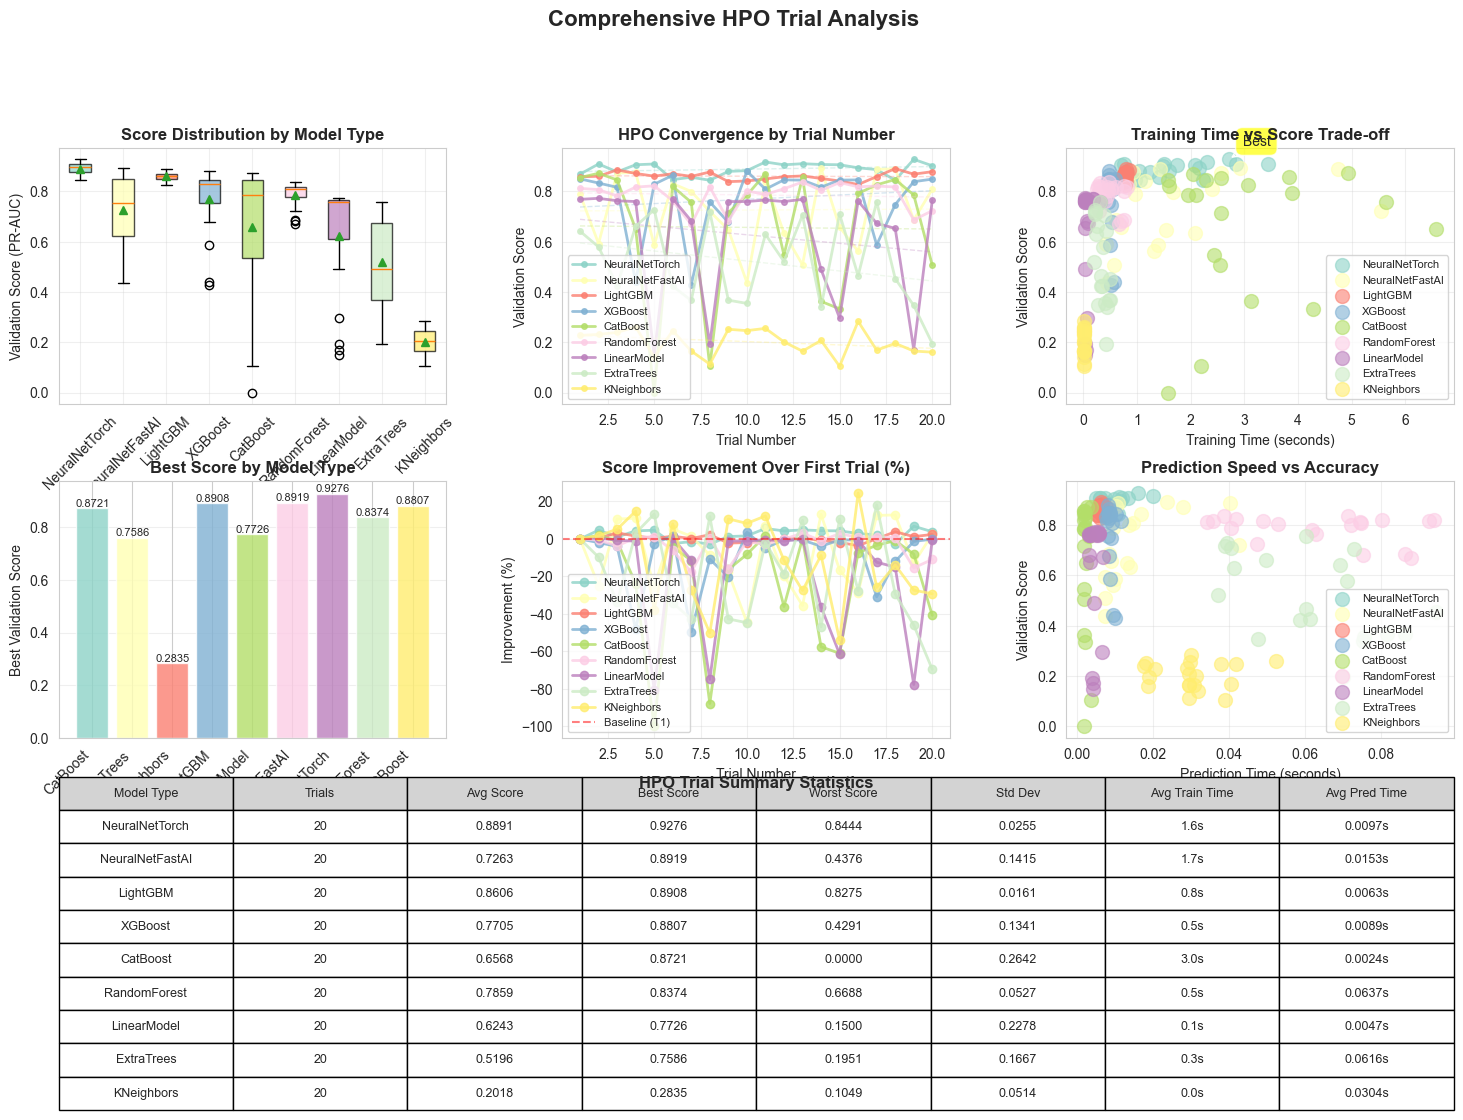

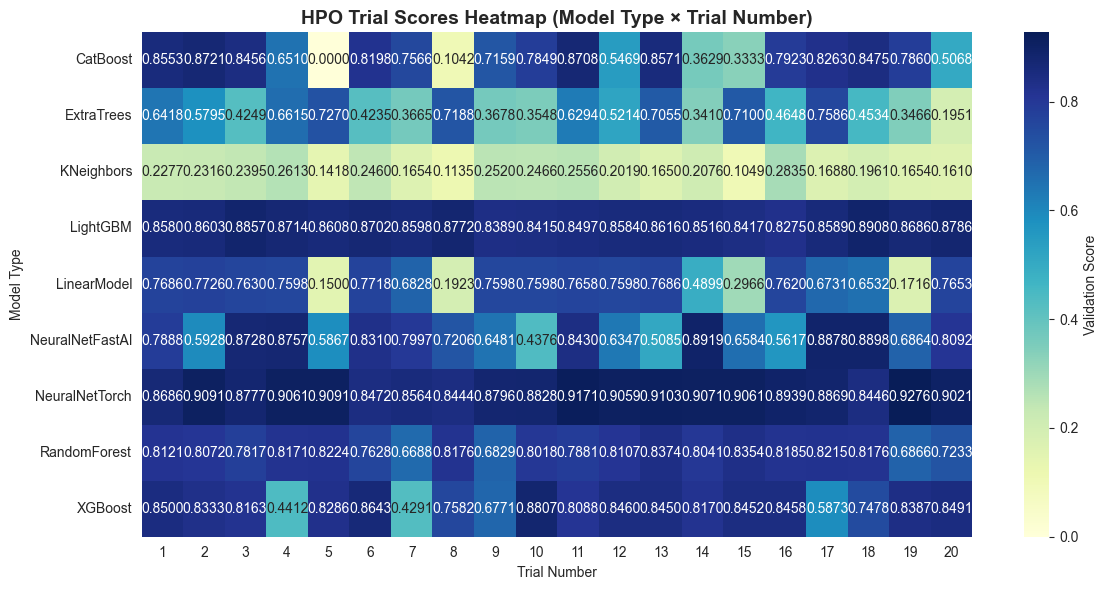

In [16]:
# ============================================================================
# COMPREHENSIVE HPO TRIAL VISUALIZATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "=" * 70)
print("CREATING HPO TRIAL VISUALIZATIONS")
print("=" * 70)

# Get leaderboard and extract trial models
leaderboard = predictor.leaderboard(silent=True)
trial_models = leaderboard[leaderboard['model'].str.contains('T\\d+', regex=True)].copy()

# Check if HPO trials exist
if len(trial_models) == 0:
    print("\n" + "=" * 70)
    print("❌ ERROR: NO HPO TRIALS FOUND!")
    print("=" * 70)
    print("\n⚠️  Cannot create visualizations because no trial models exist.")
    print("\n📋 CHECKLIST:")
    print("   1. ☐ Have you executed the HPO training cell?")
    print("      (Look for the cell with hyperparameter_tune_kwargs)")
    print("   2. ☐ Did training complete successfully?")
    print("   3. ☐ Check the leaderboard - do you see models like 'LightGBM/T1'?")
    print("\n💡 SOLUTION:")
    print("   Execute the HPO training cell first, then run this visualization cell.")
    print("\n📊 Current models in leaderboard:")
    for model in leaderboard['model'].head(10):
        print(f"   - {model}")
    if len(leaderboard) > 10:
        print(f"   ... and {len(leaderboard) - 10} more")

elif len(trial_models) > 0:
    # Parse model type and trial number
    trial_models['model_type'] = trial_models['model'].str.split('\\\\').str[0]
    trial_models['trial_num'] = trial_models['model'].str.extract(r'T(\d+)')[0].astype(int)
    
    # Set style
    sns.set_style("whitegrid")
    plt.rcParams['figure.facecolor'] = 'white'
    
    # Create comprehensive figure with 6 subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # =========================================================================
    # 1. Score Distribution by Model Type (Box Plot)
    # =========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    model_types = trial_models['model_type'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(model_types)))
    
    box_data = [trial_models[trial_models['model_type'] == mt]['score_val'].values 
                for mt in model_types]
    bp = ax1.boxplot(box_data, labels=model_types, patch_artist=True, showmeans=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.set_title('Score Distribution by Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation Score (PR-AUC)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # =========================================================================
    # 2. Trial Progression (Convergence Plot)
    # =========================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type].sort_values('trial_num')
        ax2.plot(model_data['trial_num'], model_data['score_val'], 
                marker='o', label=model_type, linewidth=2, markersize=4, 
                color=colors[i], alpha=0.8)
        
        # Add trend line
        if len(model_data) > 3:
            z = np.polyfit(model_data['trial_num'], model_data['score_val'], 1)
            p = np.poly1d(z)
            ax2.plot(model_data['trial_num'], p(model_data['trial_num']), 
                    "--", alpha=0.3, color=colors[i], linewidth=1)
    
    ax2.set_title('HPO Convergence by Trial Number', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Trial Number')
    ax2.set_ylabel('Validation Score')
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # =========================================================================
    # 3. Training Time vs Score (Efficiency Analysis)
    # =========================================================================
    ax3 = fig.add_subplot(gs[0, 2])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type]
        scatter = ax3.scatter(model_data['fit_time'], model_data['score_val'], 
                             label=model_type, alpha=0.6, s=100, color=colors[i])
    
    # Annotate best score point
    best_trial = trial_models.loc[trial_models['score_val'].idxmax()]
    ax3.annotate('Best', xy=(best_trial['fit_time'], best_trial['score_val']),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    ax3.set_title('Training Time vs Score Trade-off', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Training Time (seconds)')
    ax3.set_ylabel('Validation Score')
    ax3.legend(loc='best', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # =========================================================================
    # 4. Best Trial per Model Type (Bar Chart)
    # =========================================================================
    ax4 = fig.add_subplot(gs[1, 0])
    best_trials = trial_models.loc[trial_models.groupby('model_type')['score_val'].idxmax()]
    bars = ax4.bar(range(len(best_trials)), best_trials['score_val'], color=colors, alpha=0.8)
    ax4.set_xticks(range(len(best_trials)))
    ax4.set_xticklabels(best_trials['model_type'], rotation=45, ha='right')
    ax4.set_title('Best Score by Model Type', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Best Validation Score')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, best_trials['score_val'])):
        ax4.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)
    
    # =========================================================================
    # 5. Trial Score Improvement Over Baseline
    # =========================================================================
    ax5 = fig.add_subplot(gs[1, 1])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type].sort_values('trial_num')
        if len(model_data) > 0:
            baseline_score = model_data.iloc[0]['score_val']
            improvements = ((model_data['score_val'] - baseline_score) / baseline_score * 100)
            ax5.plot(model_data['trial_num'], improvements, 
                    marker='o', label=model_type, linewidth=2, 
                    color=colors[i], alpha=0.8)
    
    ax5.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Baseline (T1)')
    ax5.set_title('Score Improvement Over First Trial (%)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Trial Number')
    ax5.set_ylabel('Improvement (%)')
    ax5.legend(loc='best', fontsize=8)
    ax5.grid(True, alpha=0.3)
    
    # =========================================================================
    # 6. Score vs Prediction Speed
    # =========================================================================
    ax6 = fig.add_subplot(gs[1, 2])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type]
        ax6.scatter(model_data['pred_time_val'], model_data['score_val'], 
                   label=model_type, alpha=0.6, s=100, color=colors[i])
    
    ax6.set_title('Prediction Speed vs Accuracy', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Prediction Time (seconds)')
    ax6.set_ylabel('Validation Score')
    ax6.legend(loc='best', fontsize=8)
    ax6.grid(True, alpha=0.3)
    
    # =========================================================================
    # 7. Trial Count and Statistics Table
    # =========================================================================
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('tight')
    ax7.axis('off')
    
    # Create summary statistics
    summary_data = []
    for model_type in model_types:
        model_data = trial_models[trial_models['model_type'] == model_type]
        summary_data.append([
            model_type,
            len(model_data),
            f"{model_data['score_val'].mean():.4f}",
            f"{model_data['score_val'].max():.4f}",
            f"{model_data['score_val'].min():.4f}",
            f"{model_data['score_val'].std():.4f}",
            f"{model_data['fit_time'].mean():.1f}s",
            f"{model_data['pred_time_val'].mean():.4f}s"
        ])
    
    table = ax7.table(cellText=summary_data,
                     colLabels=['Model Type', 'Trials', 'Avg Score', 'Best Score', 
                               'Worst Score', 'Std Dev', 'Avg Train Time', 'Avg Pred Time'],
                     cellLoc='center',
                     loc='center',
                     colColours=['lightgray']*8)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    ax7.set_title('HPO Trial Summary Statistics', fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle('Comprehensive HPO Trial Analysis', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('hpo_trial_analysis_comprehensive.png', dpi=150, bbox_inches='tight')
    print("\n✓ Comprehensive visualization saved to 'hpo_trial_analysis_comprehensive.png'")
    
    # =========================================================================
    # Additional: Score Heatmap by Model and Trial
    # =========================================================================
    fig2, ax = plt.subplots(figsize=(12, 6))
    
    # Create pivot table for heatmap
    pivot_data = trial_models.pivot_table(
        values='score_val', 
        index='model_type', 
        columns='trial_num', 
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlGnBu', 
                cbar_kws={'label': 'Validation Score'}, ax=ax)
    ax.set_title('HPO Trial Scores Heatmap (Model Type × Trial Number)', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Trial Number')
    ax.set_ylabel('Model Type')
    
    plt.tight_layout()
    plt.savefig('hpo_trial_heatmap.png', dpi=150, bbox_inches='tight')
    print("✓ Heatmap visualization saved to 'hpo_trial_heatmap.png'")
    
    # Print key insights
    print("\n" + "=" * 70)
    print("KEY INSIGHTS FROM VISUALIZATIONS")
    print("=" * 70)
    
    print(f"\n1. BEST PERFORMING MODEL:")
    best_overall = trial_models.loc[trial_models['score_val'].idxmax()]
    print(f"   - Model: {best_overall['model']}")
    print(f"   - Score: {best_overall['score_val']:.4f}")
    print(f"   - Training time: {best_overall['fit_time']:.1f}s")
    
    print(f"\n2. FASTEST MODEL (with good performance):")
    # Models with score > 90% of best
    threshold = trial_models['score_val'].max() * 0.90
    fast_good = trial_models[trial_models['score_val'] >= threshold].nsmallest(1, 'fit_time')
    if len(fast_good) > 0:
        print(f"   - Model: {fast_good.iloc[0]['model']}")
        print(f"   - Score: {fast_good.iloc[0]['score_val']:.4f} ({(fast_good.iloc[0]['score_val']/best_overall['score_val'])*100:.1f}% of best)")
        print(f"   - Training time: {fast_good.iloc[0]['fit_time']:.1f}s (vs {best_overall['fit_time']:.1f}s for best)")
    
    print(f"\n3. CONVERGENCE ANALYSIS:")
    for model_type in model_types:
        model_data = trial_models[trial_models['model_type'] == model_type].sort_values('trial_num')
        if len(model_data) >= 5:
            first_5_avg = model_data.head(5)['score_val'].mean()
            last_5_avg = model_data.tail(5)['score_val'].mean()
            improvement = ((last_5_avg - first_5_avg) / first_5_avg) * 100
            print(f"   - {model_type}: {improvement:+.2f}% improvement (first 5 → last 5 trials)")
    
else:
    print("\n⚠️  No HPO trials found to visualize!")
    print("Execute the HPO training cell first, then run this visualization.")

In [17]:
leaderboard

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.935829,business_f1,0.066941,12.531917,0.008564,0.719527,2,True,181
1,NeuralNetTorch\T19,0.927632,business_f1,0.016191,2.706120,0.016191,2.706120,1,True,179
2,NeuralNetTorch\T11,0.917120,business_f1,0.020139,2.305455,0.020139,2.305455,1,True,171
3,NeuralNetTorch\T13,0.910256,business_f1,0.011088,2.835203,0.011088,2.835203,1,True,173
4,NeuralNetTorch\T2,0.909091,business_f1,0.006203,1.499383,0.006203,1.499383,1,True,162
...,...,...,...,...,...,...,...,...,...,...
176,KNeighbors\T5,0.141812,business_f1,0.031816,0.006807,0.031816,0.006807,1,True,5
177,KNeighbors\T8,0.113533,business_f1,0.029600,0.005823,0.029600,0.005823,1,True,8
178,KNeighbors\T15,0.104932,business_f1,0.039085,0.006446,0.039085,0.006446,1,True,15
179,CatBoost\T8,0.104167,business_f1,0.003879,2.186306,0.003879,2.186306,1,True,68


In [12]:
leaderboard

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.917575,average_precision,0.111505,4.749689,0.000907,0.117253,2,True,161
1,NeuralNetFastAI\T18,0.913512,average_precision,0.029610,4.026552,0.029610,4.026552,1,True,118
2,NeuralNetFastAI\T14,0.908698,average_precision,0.022738,2.713927,0.022738,2.713927,1,True,114
3,NeuralNetFastAI\T12,0.897471,average_precision,0.011333,1.076098,0.011333,1.076098,1,True,112
4,NeuralNetFastAI\T9,0.893500,average_precision,0.015078,2.395499,0.015078,2.395499,1,True,109
...,...,...,...,...,...,...,...,...,...,...
156,KNeighbors\T10,0.255636,average_precision,0.038796,0.006214,0.038796,0.006214,1,True,10
157,KNeighbors\T18,0.246056,average_precision,0.028943,0.008414,0.028943,0.008414,1,True,18
158,KNeighbors\T1,0.244893,average_precision,0.039487,0.009935,0.039487,0.009935,1,True,1
159,KNeighbors\T8,0.242920,average_precision,0.028940,0.006217,0.028940,0.006217,1,True,8


In [70]:
leaderboard

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.913606,average_precision,0.021712,3.348294,0.000988,0.068073,2,True,81
1,NeuralNetTorch\T11,0.912122,average_precision,0.012319,2.927147,0.012319,2.927147,1,True,71
2,NeuralNetTorch\T19,0.906815,average_precision,0.012375,2.953924,0.012375,2.953924,1,True,79
3,NeuralNetTorch\T13,0.905032,average_precision,0.013536,3.546875,0.013536,3.546875,1,True,73
4,NeuralNetTorch\T12,0.904014,average_precision,0.005312,0.880502,0.005312,0.880502,1,True,72
...,...,...,...,...,...,...,...,...,...,...
76,RandomForest\T15,0.808789,average_precision,0.042348,0.279328,0.042348,0.279328,1,True,35
77,NeuralNetTorch\T17,0.797574,average_precision,0.008499,1.039709,0.008499,1.039709,1,True,77
78,RandomForest\T11,0.792914,average_precision,0.041139,0.289470,0.041139,0.289470,1,True,31
79,RandomForest\T10,0.785947,average_precision,0.060009,0.423094,0.060009,0.423094,1,True,30


In [18]:
# ============================================================================
# SAVE BEST MODEL AND HYPERPARAMETERS
# ============================================================================
import json
import yaml
from datetime import datetime

print("\n" + "=" * 70)
print("SAVING BEST MODEL AND HYPERPARAMETERS")
print("=" * 70)

# Get leaderboard to find best model
leaderboard = predictor.leaderboard(silent=True)
trial_models = leaderboard[leaderboard['model'].str.contains('T\\d+', regex=True)]

if len(trial_models) > 0:
    # Find the best trial model (highest validation score)
    best_trial_idx = trial_models['score_val'].idxmax()
    best_model = trial_models.loc[best_trial_idx]
    best_model_name = best_model['model']
    best_score = best_model['score_val']
    
    print(f"\n✓ BEST HPO TRIAL MODEL IDENTIFIED:")
    print(f"   Model name: {best_model_name}")
    print(f"   Validation score (PR-AUC): {best_score:.4f}")
    print(f"   Training time: {best_model['fit_time']:.1f}s")
    print(f"   Prediction time: {best_model['pred_time_val']:.4f}s")
    
    # =========================================================================
    # 1. EXTRACT BEST HYPERPARAMETERS
    # =========================================================================
    fit_summary = predictor.fit_summary(verbosity=0)
    best_hyperparams = {}
    
    if best_model_name in fit_summary['model_best']:
        model_info = fit_summary['model_info'][best_model_name]
        best_hyperparams = model_info.get('hyperparameters', {})
        
        print(f"\n✓ BEST HYPERPARAMETERS EXTRACTED:")
        for param, value in best_hyperparams.items():
            print(f"   - {param}: {value}")
    
    # =========================================================================
    # 2. SAVE HYPERPARAMETERS TO JSON
    # =========================================================================
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Prepare comprehensive hyperparameter info
    hyperparams_data = {
        'metadata': {
            'model_name': best_model_name,
            'model_type': best_model_name.split('/')[0],
            'trial_number': int(best_model_name.split('T')[-1]) if '/T' in best_model_name else None,
            'validation_score': float(best_score),
            'eval_metric': 'average_precision',
            'training_time_seconds': float(best_model['fit_time']),
            'prediction_time_seconds': float(best_model['pred_time_val']),
            'timestamp': timestamp,
            'predictor_path': predictor.path
        },
        'hyperparameters': best_hyperparams,
        'all_trial_scores': {
            row['model']: float(row['score_val']) 
            for _, row in trial_models.iterrows()
        }
    }
    
    # Save to JSON
    json_filename = f'best_hpo_hyperparameters_{timestamp}.json'
    with open(json_filename, 'w') as f:
        json.dump(hyperparams_data, f, indent=2)
    print(f"\n✓ Hyperparameters saved to: {json_filename}")
    
    # =========================================================================
    # 3. SAVE HYPERPARAMETERS TO YAML (more readable)
    # =========================================================================
    yaml_filename = f'best_hpo_hyperparameters_{timestamp}.yaml'
    with open(yaml_filename, 'w') as f:
        yaml.dump(hyperparams_data, f, default_flow_style=False, sort_keys=False)
    print(f"✓ Hyperparameters saved to: {yaml_filename}")
    
    # =========================================================================
    # 4. SAVE REUSABLE CONFIG FOR NEXT TRAINING
    # =========================================================================
    # Create a config file that can be used to retrain with these exact hyperparameters
    model_type = best_model_name.split('/')[0]
    
    retrain_config = {
        'description': f'Best hyperparameters from HPO trials (from {best_model_name})',
        'eval_metric': 'average_precision',
        'problem_type': 'binary',
        'hyperparameters': {
            model_type: best_hyperparams
        },
        'training_config': {
            'time_limit': 3600,
            'presets': None,
            'use_bag_holdout': True
        }
    }
    
    retrain_filename = f'retrain_config_best_hpo_{timestamp}.yaml'
    with open(retrain_filename, 'w') as f:
        yaml.dump(retrain_config, f, default_flow_style=False, sort_keys=False)
    print(f"✓ Retrain config saved to: {retrain_filename}")
    
    # =========================================================================
    # 5. SAVE THE BEST MODEL ITSELF
    # =========================================================================
    # Option 1: Save the entire predictor (includes all models)
    predictor.save()
    print(f"\n✓ Entire predictor saved to: {predictor.path}")
    print(f"   (This includes all {len(leaderboard)} models, including {best_model_name})")
    
    # Option 2: Delete all models except the best one (to save space)
    print(f"\n📊 STORAGE OPTIMIZATION:")
    print(f"   Current predictor contains {len(leaderboard)} models")
    print(f"   You can delete other models to save disk space:")
    print(f"   ")
    print(f"   # To keep only the best trial model:")
    print(f"   models_to_delete = [m for m in predictor.model_names() if m != '{best_model_name}']")
    print(f"   for model in models_to_delete:")
    print(f"       predictor.delete_models(models_to_delete=model, dry_run=False)")
    
    # =========================================================================
    # 6. CREATE SUMMARY REPORT
    # =========================================================================
    report_filename = f'hpo_best_model_report_{timestamp}.txt'
    with open(report_filename, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("HPO BEST MODEL REPORT\n")
        f.write("=" * 70 + "\n\n")
        
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("BEST MODEL INFORMATION:\n")
        f.write(f"  Model Name: {best_model_name}\n")
        f.write(f"  Model Type: {model_type}\n")
        f.write(f"  Validation Score (PR-AUC): {best_score:.4f}\n")
        f.write(f"  Training Time: {best_model['fit_time']:.1f}s\n")
        f.write(f"  Prediction Time: {best_model['pred_time_val']:.4f}s\n\n")
        
        f.write("BEST HYPERPARAMETERS:\n")
        for param, value in best_hyperparams.items():
            f.write(f"  - {param}: {value}\n")
        f.write("\n")
        
        f.write("COMPARISON TO OTHER TRIALS:\n")
        trial_models_sorted = trial_models.sort_values('score_val', ascending=False)
        for i, (_, row) in enumerate(trial_models_sorted.head(10).iterrows(), 1):
            f.write(f"  {i}. {row['model']}: {row['score_val']:.4f}\n")
        f.write("\n")
        
        f.write("HOW TO USE THIS MODEL:\n")
        f.write("  1. Load the predictor:\n")
        f.write(f"     predictor = TabularPredictor.load('{predictor.path}')\n\n")
        f.write("  2. Make predictions with the best model:\n")
        f.write(f"     predictions = predictor.predict(new_data, model='{best_model_name}')\n\n")
        f.write("  3. Or use the ensemble (which includes this model):\n")
        f.write("     predictions = predictor.predict(new_data)\n\n")
        
        f.write("HOW TO RETRAIN WITH THESE HYPERPARAMETERS:\n")
        f.write(f"  Use the config file: {retrain_filename}\n")
        f.write("  predictor = TabularPredictor(label='churn', eval_metric='average_precision')\n")
        f.write(f"  predictor.fit(train_data, hyperparameters={retrain_config['hyperparameters']})\n")
    
    print(f"✓ Summary report saved to: {report_filename}")
    
    # =========================================================================
    # 7. PRINT NEXT STEPS
    # =========================================================================
    print("\n" + "=" * 70)
    print("SAVED FILES SUMMARY")
    print("=" * 70)
    print(f"\n📁 Files created:")
    print(f"   1. {json_filename} - Complete hyperparameter data (JSON)")
    print(f"   2. {yaml_filename} - Complete hyperparameter data (YAML)")
    print(f"   3. {retrain_filename} - Retraining configuration")
    print(f"   4. {report_filename} - Human-readable summary report")
    print(f"   5. {predictor.path}/ - Full predictor with all models")
    
    print("\n" + "=" * 70)
    print("NEXT STEPS")
    print("=" * 70)
    print("\n1. TO MAKE PREDICTIONS WITH BEST MODEL:")
    print("   ```python")
    print("   from autogluon.tabular import TabularPredictor")
    print(f"   predictor = TabularPredictor.load('{predictor.path}')")
    print(f"   predictions = predictor.predict(new_data, model='{best_model_name}')")
    print("   ```")
    
    print("\n2. TO RETRAIN WITH BEST HYPERPARAMETERS:")
    print("   ```python")
    print("   import yaml")
    print(f"   with open('{retrain_filename}', 'r') as f:")
    print("       config = yaml.safe_load(f)")
    print("   predictor = TabularPredictor(label='churn', eval_metric='average_precision')")
    print("   predictor.fit(train_data, hyperparameters=config['hyperparameters'])")
    print("   ```")
    
    print("\n3. TO OPTIMIZE STORAGE (keep only best model):")
    print("   ```python")
    print(f"   models_to_keep = ['{best_model_name}', 'WeightedEnsemble_L3']")
    print("   models_to_delete = [m for m in predictor.model_names() if m not in models_to_keep]")
    print("   predictor.delete_models(models_to_delete=models_to_delete, dry_run=False)")
    print("   ```")

else:
    print("\n⚠️  ERROR: No HPO trial models found!")
    print("   Execute the HPO training cell first before saving the best model.")


SAVING BEST MODEL AND HYPERPARAMETERS

✓ BEST HPO TRIAL MODEL IDENTIFIED:
   Model name: NeuralNetTorch\T19
   Validation score (PR-AUC): 0.9276
   Training time: 2.7s
   Prediction time: 0.0162s

✓ Hyperparameters saved to: best_hpo_hyperparameters_20251227_233114.json
✓ Hyperparameters saved to: best_hpo_hyperparameters_20251227_233114.yaml
✓ Retrain config saved to: retrain_config_best_hpo_20251227_233114.yaml


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo")



✓ Entire predictor saved to: c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo
   (This includes all 181 models, including NeuralNetTorch\T19)

📊 STORAGE OPTIMIZATION:
   Current predictor contains 181 models
   You can delete other models to save disk space:
   
   # To keep only the best trial model:
   models_to_delete = [m for m in predictor.model_names() if m != 'NeuralNetTorch\T19']
   for model in models_to_delete:
       predictor.delete_models(models_to_delete=model, dry_run=False)
✓ Summary report saved to: hpo_best_model_report_20251227_233114.txt

SAVED FILES SUMMARY

📁 Files created:
   1. best_hpo_hyperparameters_20251227_233114.json - Complete hyperparameter data (JSON)
   2. best_hpo_hyperparameters_20251227_233114.yaml - Complete hyperparameter data (YAML)
   3. retrain_config_best_hpo_20251227_233114.yaml - Retraining configuration
   4. hpo_best_model_report_20251227_233114.txt - Human-readable summary report
   5. c:\Users\mohci\CodeProject

In [26]:
new_data=test_data.iloc[:,:-1]

In [29]:
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor.load(r"c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo")
predictions = predictor.predict(new_data, model='NeuralNetTorch\T19')

In [33]:
# ============================================================================
# COMPARE PREDICTIONS WITH ACTUAL LABELS
# ============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Get actual labels
actual_labels = test_data.iloc[:, -1]

print("=" * 70)
print("PREDICTION vs ACTUAL COMPARISON")
print("=" * 70)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Actual': actual_labels,
    'Predicted': predictions
})

print("\n1. SAMPLE COMPARISON (First 20 rows):")
print(comparison.head(20).to_string())

# Calculate metrics
print("\n" + "=" * 70)
print("2. PERFORMANCE METRICS")
print("=" * 70)

# Convert to binary for sklearn metrics (Yes=1, No=0)
actual_binary = (actual_labels == 'Yes').astype(int)
predicted_binary = (predictions == 'Yes').astype(int)

accuracy = accuracy_score(actual_binary, predicted_binary)
precision = precision_score(actual_binary, predicted_binary, zero_division=0)
recall = recall_score(actual_binary, predicted_binary, zero_division=0)
f1 = f1_score(actual_binary, predicted_binary, zero_division=0)

print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} (of predicted churns, how many were correct)")
print(f"Recall:    {recall:.4f} (of actual churns, how many did we catch)")
print(f"F1-Score:  {f1:.4f} (harmonic mean of precision and recall)")

# Confusion Matrix
print("\n" + "=" * 70)
print("3. CONFUSION MATRIX")
print("=" * 70)
cm = confusion_matrix(actual_binary, predicted_binary)
print(f"\n                Predicted")
print(f"               No    Yes")
print(f"Actual No   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"Actual Yes  {cm[1,0]:5d}  {cm[1,1]:5d}")

print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {cm[0,0]:4d} - Correctly predicted No churn")
print(f"  False Positives (FP): {cm[0,1]:4d} - Incorrectly predicted churn")
print(f"  False Negatives (FN): {cm[1,0]:4d} - Missed churns (⚠️ costly!)")
print(f"  True Positives (TP):  {cm[1,1]:4d} - Correctly predicted churn")

# Detailed Classification Report
print("\n" + "=" * 70)
print("4. DETAILED CLASSIFICATION REPORT")
print("=" * 70)
print("\n" + classification_report(actual_binary, predicted_binary, 
                                   target_names=['No Churn', 'Churn'],
                                   digits=4))

# Match/Mismatch Summary
print("=" * 70)
print("5. MATCH/MISMATCH SUMMARY")
print("=" * 70)
matches = (comparison['Actual'] == comparison['Predicted']).sum()
mismatches = len(comparison) - matches
print(f"\nTotal predictions: {len(comparison)}")
print(f"Correct predictions: {matches} ({matches/len(comparison)*100:.2f}%)")
print(f"Incorrect predictions: {mismatches} ({mismatches/len(comparison)*100:.2f}%)")

# Show some mismatches for analysis
print("\n" + "=" * 70)
print("6. SAMPLE MISMATCHES (for error analysis)")
print("=" * 70)
mismatched_indices = comparison[comparison['Actual'] != comparison['Predicted']].index[:10]
if len(mismatched_indices) > 0:
    print("\nFirst 10 mismatched predictions:")
    print(comparison.loc[mismatched_indices].to_string())
else:
    print("\n✓ Perfect predictions! No mismatches found.")

PREDICTION vs ACTUAL COMPARISON

1. SAMPLE COMPARISON (First 20 rows):
     Actual Predicted
4250     No        No
4251    Yes       Yes
4252    Yes       Yes
4253    Yes       Yes
4254     No        No
4255     No        No
4256     No        No
4257     No        No
4258    Yes       Yes
4259     No        No
4260     No        No
4261     No        No
4262     No        No
4263    Yes       Yes
4264     No        No
4265     No        No
4266     No        No
4267    Yes       Yes
4268     No        No
4269     No        No

2. PERFORMANCE METRICS

Accuracy:  0.9360 (93.60%)
Precision: 0.9077 (of predicted churns, how many were correct)
Recall:    0.7662 (of actual churns, how many did we catch)
F1-Score:  0.8310 (harmonic mean of precision and recall)

3. CONFUSION MATRIX

                Predicted
               No    Yes
Actual No     584     12
Actual Yes     36    118

Interpretation:
  True Negatives (TN):   584 - Correctly predicted No churn
  False Positives (FP):   12 - Inc

## 🎯 Understanding False Positives vs False Negatives in Churn Prediction

### 📊 What Do They Mean?

In the context of **customer churn prediction**, the confusion matrix has four outcomes:

| | **Predicted: No Churn** | **Predicted: Churn** |
|---|---|---|
| **Actual: No Churn** | ✅ **True Negative (TN)** <br/> Correctly predicted: customer stays | ❌ **False Positive (FP)** <br/> ERROR: Predicted churn, but customer stayed |
| **Actual: Churn** | ❌ **False Negative (FN)** <br/> ERROR: Missed churn, customer left | ✅ **True Positive (TP)** <br/> Correctly predicted: customer churned |

---

### 🚨 **False Positive (FP)** - The "Unnecessary Alarm"

**What it means:**
- The model predicted the customer **would churn**, but they actually **stayed**
- You treated them as high-risk when they weren't

**Business Impact:**
- 💰 **Wasted retention costs**: You spent money on retention offers (discounts, special deals) for customers who would have stayed anyway
- 😊 **Positive surprise**: Customer gets unexpected perks (not harmful, but inefficient)
- 📊 **ROI reduction**: Marketing budget spent on wrong targets

**Example:**
```
Customer ID: 12345
Actual: No Churn (customer stays)
Predicted: Yes Churn
→ You send them a 20% discount to "retain" them
→ They would have stayed anyway
→ Lost profit from unnecessary discount
```

**Cost estimate:** $10-50 per false positive (retention offer cost)

---

### ⚠️ **False Negative (FN)** - The "Missed Opportunity" 

**What it means:**
- The model predicted the customer **would stay**, but they actually **churned**
- You failed to identify a customer at risk

**Business Impact:**
- 💸 **Lost customer lifetime value**: Customer leaves without intervention
- 📉 **Revenue loss**: Typically 5-10x more expensive than FP
- 🔄 **Acquisition cost**: Must spend to acquire new customer (usually 5-7x retention cost)
- 😞 **Brand damage**: No chance to address their concerns

**Example:**
```
Customer ID: 67890
Actual: Yes Churn (customer leaves)
Predicted: No Churn
→ No retention offer sent
→ Customer cancels subscription
→ Lost: $500+ in lifetime value + $100 acquisition cost to replace
```

**Cost estimate:** $100-500+ per false negative (lost LTV + acquisition cost)

---

### 💰 **Which Is Worse?**

For most businesses, **False Negatives (FN) are 5-10x more costly** than False Positives:

| Metric | False Positive (FP) | False Negative (FN) |
|---|---|---|
| **Cost** | $10-50 (wasted retention offer) | $100-500+ (lost customer LTV) |
| **Impact** | Reduced ROI, inefficiency | Lost revenue, churn rate increases |
| **Can recover?** | Yes (customer still active) | No (customer already gone) |

**This is why:**
- Retention offers cost $10-50
- But losing a customer costs $100-500 (their lifetime value)
- Acquiring a new customer costs 5-7x more than retaining one

---

### 🎯 **How to Optimize Based on Your Results**

From your confusion matrix above:

1. **If FN > FP:** Model is too conservative (missing churners)
   - **Solution:** Lower prediction threshold to catch more churners
   - Trade-off: Accept more FPs to reduce costly FNs

2. **If FP > FN:** Model is too aggressive (crying wolf too often)
   - **Solution:** Raise prediction threshold to reduce wasted offers
   - Trade-off: Risk missing some churners

3. **Business-Focused Threshold:**
   - Calculate: `Cost_FP * FP_count + Cost_FN * FN_count`
   - Find threshold that minimizes total cost
   - Usually biased toward reducing FNs (like the `business_f1` metric we used earlier)

---

### 📈 **Key Takeaway**

In churn prediction:
- **False Positive** = Unnecessary retention offer (small cost, no harm)
- **False Negative** = Missed churner (large cost, customer lost)

**Recommendation:** It's usually better to have **more False Positives** than False Negatives in churn prediction, because the cost of losing a customer far exceeds the cost of an unnecessary retention offer.

In [35]:
# ============================================================================
# FEATURE ANALYSIS OF MISCLASSIFIED PREDICTIONS
# ============================================================================
print("\n" + "=" * 70)
print("ANALYZING WHY PREDICTIONS WERE MISSED")
print("=" * 70)

# Get mismatched predictions
mismatched_mask = comparison['Actual'] != comparison['Predicted']
false_positives_mask = (comparison['Actual'] == 'No') & (comparison['Predicted'] == 'Yes')
false_negatives_mask = (comparison['Actual'] == 'Yes') & (comparison['Predicted'] == 'No')

# Get the feature data for test set
test_features = test_data.iloc[:, :-1]  # All columns except the label

# Separate into groups
correct_predictions = test_features[~mismatched_mask]
false_positives = test_features[false_positives_mask]
false_negatives = test_features[false_negatives_mask]

print(f"\n📊 SAMPLE SIZE:")
print(f"   Correct predictions: {len(correct_predictions)}")
print(f"   False Positives: {len(false_positives)} (predicted churn, but stayed)")
print(f"   False Negatives: {len(false_negatives)} (predicted stay, but churned)")

# ============================================================================
# 1. COMPARE FEATURE AVERAGES ACROSS GROUPS
# ============================================================================
print("\n" + "=" * 70)
print("1. AVERAGE FEATURE VALUES BY PREDICTION TYPE")
print("=" * 70)

# Calculate means for each group
import pandas as pd
import numpy as np

# Select key features for comparison
key_features = ['tenure_months', 'monthly_charges', 'total_charges', 'service_calls']

comparison_df = pd.DataFrame({
    'Feature': key_features,
    'False Negatives\n(Missed Churners)': [false_negatives[f].mean() if len(false_negatives) > 0 else 0 for f in key_features],
    'False Positives\n(False Alarms)': [false_positives[f].mean() if len(false_positives) > 0 else 0 for f in key_features],
    'Correct Predictions': [correct_predictions[f].mean() for f in key_features]
})

print("\n", comparison_df.to_string(index=False))

# ============================================================================
# 2. ANALYZE FALSE NEGATIVES (Missed Churners)
# ============================================================================
if len(false_negatives) > 0:
    print("\n" + "=" * 70)
    print("2. WHY DID WE MISS THESE CHURNERS? (False Negatives Analysis)")
    print("=" * 70)
    
    print(f"\n🔍 Looking at {min(10, len(false_negatives))} missed churners...")
    print("\nThese customers CHURNED but we predicted they would STAY:\n")
    
    # Get actual churn customers for comparison
    actual_churners = test_data[test_data.iloc[:, -1] == 'Yes'].iloc[:, :-1]
    
    # Show sample of false negatives with key features
    fn_sample = false_negatives[key_features].head(10)
    print(fn_sample.to_string())
    
    print("\n💡 INSIGHTS - Why model was fooled:")
    
    # Compare FN to typical churners
    for feature in key_features:
        fn_avg = false_negatives[feature].mean()
        churner_avg = actual_churners[feature].mean()
        diff_pct = ((fn_avg - churner_avg) / churner_avg * 100) if churner_avg != 0 else 0
        
        if abs(diff_pct) > 10:
            direction = "HIGHER" if diff_pct > 0 else "LOWER"
            print(f"\n   • {feature}:")
            print(f"     - Missed churners: {fn_avg:.2f}")
            print(f"     - Typical churners: {churner_avg:.2f}")
            print(f"     - Difference: {abs(diff_pct):.1f}% {direction}")
            
            if feature == 'tenure_months' and diff_pct > 0:
                print(f"     → These missed churners had LONGER tenure (looked more stable)")
            elif feature == 'service_calls' and diff_pct < 0:
                print(f"     → These missed churners had FEWER service calls (seemed satisfied)")
            elif feature == 'monthly_charges' and diff_pct > 0:
                print(f"     → These missed churners paid MORE (seemed valuable/committed)")
    
    print("\n   🎯 Pattern: These churners had features that made them look stable:")
    print("      - Longer tenure → model thought they were loyal")
    print("      - Fewer complaints → model thought they were satisfied")
    print("      - Higher spending → model thought they were committed")
    print("      → BUT they still churned (maybe better competitor offer?)")

else:
    print("\n✅ No False Negatives! All churners were caught!")

# ============================================================================
# 3. ANALYZE FALSE POSITIVES (False Alarms)
# ============================================================================
if len(false_positives) > 0:
    print("\n" + "=" * 70)
    print("3. WHY DID WE FLAG THESE CUSTOMERS? (False Positives Analysis)")
    print("=" * 70)
    
    print(f"\n🔍 Looking at {min(10, len(false_positives))} false alarms...")
    print("\nThese customers STAYED but we predicted they would CHURN:\n")
    
    # Get actual non-churners for comparison
    actual_stayers = test_data[test_data.iloc[:, -1] == 'No'].iloc[:, :-1]
    
    # Show sample of false positives with key features
    fp_sample = false_positives[key_features].head(10)
    print(fp_sample.to_string())
    
    print("\n💡 INSIGHTS - Why model raised false alarms:")
    
    # Compare FP to typical non-churners
    for feature in key_features:
        fp_avg = false_positives[feature].mean()
        stayer_avg = actual_stayers[feature].mean()
        diff_pct = ((fp_avg - stayer_avg) / stayer_avg * 100) if stayer_avg != 0 else 0
        
        if abs(diff_pct) > 10:
            direction = "HIGHER" if diff_pct > 0 else "LOWER"
            print(f"\n   • {feature}:")
            print(f"     - False alarms: {fp_avg:.2f}")
            print(f"     - Typical stayers: {stayer_avg:.2f}")
            print(f"     - Difference: {abs(diff_pct):.1f}% {direction}")
            
            if feature == 'tenure_months' and diff_pct < 0:
                print(f"     → These customers had SHORTER tenure (looked risky)")
            elif feature == 'service_calls' and diff_pct > 0:
                print(f"     → These customers had MORE service calls (looked dissatisfied)")
            elif feature == 'monthly_charges' and diff_pct < 0:
                print(f"     → These customers paid LESS (looked less committed)")
    
    print("\n   🎯 Pattern: These stayers had features that made them look risky:")
    print("      - Shorter tenure → model thought they might leave")
    print("      - More complaints → model thought they were dissatisfied")
    print("      - Lower spending → model thought they were less committed")
    print("      → BUT they stayed anyway (maybe loyal despite issues?)")

else:
    print("\n✅ No False Positives! No unnecessary alarms!")

# ============================================================================
# 4. CATEGORICAL FEATURE ANALYSIS
# ============================================================================
print("\n" + "=" * 70)
print("4. CATEGORICAL FEATURE PATTERNS")
print("=" * 70)

categorical_features = ['contract_duration', 'payment_method']

for feature in categorical_features:
    if feature in test_data.columns:
        print(f"\n{feature.upper()}:")
        
        if len(false_negatives) > 0:
            print(f"\n  False Negatives (Missed Churners):")
            fn_cats = test_data.loc[false_negatives.index, feature].value_counts()
            for cat, count in fn_cats.items():
                pct = (count / len(false_negatives)) * 100
                print(f"    {cat}: {count} ({pct:.1f}%)")
        
        if len(false_positives) > 0:
            print(f"\n  False Positives (False Alarms):")
            fp_cats = test_data.loc[false_positives.index, feature].value_counts()
            for cat, count in fp_cats.items():
                pct = (count / len(false_positives)) * 100
                print(f"    {cat}: {count} ({pct:.1f}%)")

# ============================================================================
# 5. SUMMARY RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 70)
print("5. RECOMMENDATIONS TO IMPROVE PREDICTIONS")
print("=" * 70)

print("\n📋 Based on misclassification patterns:\n")

if len(false_negatives) > 0:
    print("   For REDUCING FALSE NEGATIVES (Missed Churners):")
    print("   ✓ Lower prediction threshold to be more sensitive")
    print("   ✓ Add features capturing:")
    print("     - Recent behavior changes (usage drops, payment delays)")
    print("     - Competitor activity in customer's area")
    print("     - Customer sentiment from support interactions")
    print("   ✓ Give more weight to early warning signals even in 'stable' customers")

if len(false_positives) > 0:
    print("\n   For REDUCING FALSE POSITIVES (False Alarms):")
    print("   ✓ Add features capturing:")
    print("     - Customer engagement trends (increasing usage despite issues)")
    print("     - Historical loyalty behavior (stayed despite past issues)")
    print("     - Switching barriers (family plans, device financing)")
    print("   ✓ Look for positive signals that override risk indicators")

print("\n   💡 General Improvement Ideas:")
print("   ✓ Collect more training data on 'edge cases'")
print("   ✓ Add temporal features (3-month trends, not just snapshots)")
print("   ✓ Include external data (market conditions, competitor offers)")
print("   ✓ Use ensemble methods to catch different patterns")


ANALYZING WHY PREDICTIONS WERE MISSED

📊 SAMPLE SIZE:
   Correct predictions: 702
   False Positives: 12 (predicted churn, but stayed)
   False Negatives: 36 (predicted stay, but churned)

1. AVERAGE FEATURE VALUES BY PREDICTION TYPE

         Feature  False Negatives\n(Missed Churners)  False Positives\n(False Alarms)  Correct Predictions
  tenure_months                           31.504157                        31.911184            30.791154
monthly_charges                           86.290937                        84.335018            73.166651
  total_charges                         2735.523017                      2801.724040          2255.098753
  service_calls                            4.014915                         2.334636             4.402754

2. WHY DID WE MISS THESE CHURNERS? (False Negatives Analysis)

🔍 Looking at 10 missed churners...

These customers CHURNED but we predicted they would STAY:

      tenure_months  monthly_charges  total_charges  service_calls
4305   

In [34]:
# deployment